# CP1 — Statistical Computing with R & Python
## Parte 1 — Coleta, Exploração, Tratamento e Validação dos Dados
### Dataset: IRIS

**Integrantes:** 
Rafael Medici | RM 576249


## 1. Coleta dos dados e fonte utilizada

O dataset utilizado é o **IRIS**, um dos conjuntos de dados mais conhecidos em Machine Learning. Ele está disponível nativamente na biblioteca `scikit-learn`, não sendo necessário download externo.

Contém **150 amostras** de flores, divididas em **3 espécies** (*setosa*, *versicolor*, *virginica*), com **4 atributos numéricos** medidos em centímetros: comprimento e largura da sépala e da pétala.

In [4]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Carregamento do dataset IRIS diretamente do scikit-learn
iris = load_iris(as_frame=True)
df = iris.frame.copy()

# Criação de uma coluna com o nome da espécie (mais legível que o número da classe)
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

# Visualização das primeiras linhas
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploração dos dados

Antes de qualquer tratamento, é preciso entender o formato e as características do dataset: quantidade de registros, tipos de dados e distribuição das classes.

In [5]:
# Dimensões do dataset: (número de linhas, número de colunas)
print("Dimensões do dataset:", df.shape)
print()

# Tipos de dados de cada coluna
df.info()


Dimensões do dataset: (150, 6)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [6]:
# Estatísticas descritivas das variáveis numéricas (média, desvio-padrão, mínimo, máximo, quartis)
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
# Verificação do balanceamento das classes (quantidade de amostras por espécie)
print("Distribuição das classes (espécies):")
df['species'].value_counts()


Distribuição das classes (espécies):


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3. Estrutura e características dos dados

Com base na exploração acima, resume-se o dataset da seguinte forma:

- **150 registros**, **4 variáveis preditoras numéricas contínuas** (todas em centímetros) e **1 variável alvo categórica** (espécie).
- **3 classes perfeitamente balanceadas** (50 amostras cada), o que é favorável para evitar viés na etapa de classificação.
- Todas as variáveis estão na **mesma unidade de medida**, o que favorece o uso de algoritmos baseados em distância — como o KNN, que será utilizado na Parte 2.

## 4. Identificação e tratamento de valores ausentes

Verifica-se a existência de células vazias (valores nulos/NaN) em cada coluna do dataset.

In [8]:
# Contagem de valores ausentes (nulos) por coluna
valores_ausentes = df.isnull().sum()
print("Valores ausentes por coluna:")
print(valores_ausentes)
print()
print("Total de valores ausentes no dataset:", valores_ausentes.sum())


Valores ausentes por coluna:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Total de valores ausentes no dataset: 0


**Resultado:** não há valores ausentes no dataset. Ainda assim, a verificação foi realizada como parte do processo padrão de validação de qualidade de dados — caso houvesse valores ausentes, o tratamento indicado seria a remoção da linha ou a imputação pela média/mediana da coluna, por espécie.

## 5. Identificação e tratamento de duplicidades

Verifica-se a existência de linhas duplicadas — ou seja, duas flores com exatamente as mesmas quatro medidas.

In [9]:
# Contagem de linhas duplicadas
duplicatas = df.duplicated().sum()
print("Número de linhas duplicadas:", duplicatas)

if duplicatas > 0:
    print("\nLinhas duplicadas encontradas:")
    display(df[df.duplicated(keep=False)])
    # Remoção das duplicatas, mantendo apenas a primeira ocorrência
    df = df.drop_duplicates().reset_index(drop=True)
    print("\nDuplicatas removidas. Novo shape:", df.shape)
else:
    print("Nenhuma duplicata encontrada — nenhum tratamento necessário.")


Número de linhas duplicadas: 1

Linhas duplicadas encontradas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
101,5.8,2.7,5.1,1.9,2,virginica
142,5.8,2.7,5.1,1.9,2,virginica



Duplicatas removidas. Novo shape: (149, 6)


## 6. Identificação e tratamento de inconsistências

A verificação de inconsistências é feita em duas frentes:

1. **Impossibilidade física:** nenhuma medida pode ser menor ou igual a zero (não existe pétala com comprimento negativo, por exemplo).
2. **Outliers estatísticos:** valores muito fora do padrão de cada coluna, identificados pelo método do Intervalo Interquartil (IQR).

In [10]:
colunas_numericas = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Verificação de valores fisicamente impossíveis (<= 0)
inconsistencias = (df[colunas_numericas] <= 0).sum()
print("Valores <= 0 por coluna (inconsistência física):")
print(inconsistencias)


Valores <= 0 por coluna (inconsistência física):
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


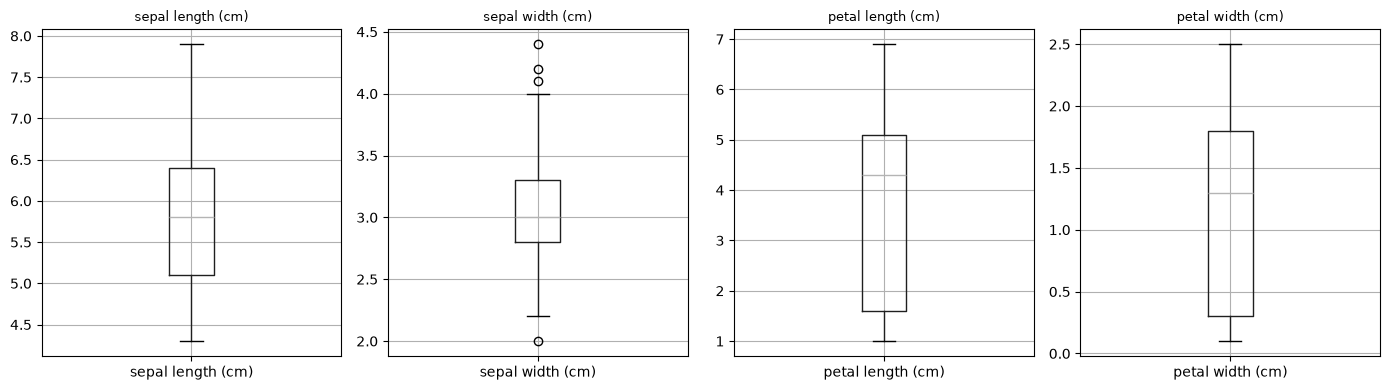

In [11]:
import matplotlib.pyplot as plt

# Boxplot de cada variável numérica para identificação visual de outliers
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, colunas_numericas):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


In [12]:
# Estatísticas de referência para justificar os pontos identificados como outliers no boxplot
col = 'sepal width (cm)'

print(f"Média geral de {col}: {df[col].mean():.2f} cm")
print(f"Desvio padrão geral: {df[col].std():.2f} cm")
print()
print(f"Média de {col} por espécie:")
print(df.groupby('species')[col].mean().round(2))
print()

# Os valores mais extremos da coluna, que aparecem como pontos isolados fora dos "bigodes" no boxplot
print("Valores mais altos (maiores extremos observados no boxplot):")
print(df.nlargest(3, col)[[col, 'species']])
print()
print("Valores mais baixos (menores extremos observados no boxplot):")
print(df.nsmallest(1, col)[[col, 'species']])

Média geral de sepal width (cm): 3.06 cm
Desvio padrão geral: 0.44 cm

Média de sepal width (cm) por espécie:
species
setosa        3.43
versicolor    2.77
virginica     2.98
Name: sepal width (cm), dtype: float64

Valores mais altos (maiores extremos observados no boxplot):
    sepal width (cm) species
15               4.4  setosa
33               4.2  setosa
32               4.1  setosa

Valores mais baixos (menores extremos observados no boxplot):
    sepal width (cm)     species
60               2.0  versicolor


**Resultado e decisão tomada:** não há valores fisicamente impossíveis. No boxplot, observam-se alguns pontos isolados (outliers) em `sepal width (cm)`: a espécie *setosa* tem, em média, sépala mais larga que as demais (3,43 cm contra 2,77 e 2,97 cm), o que explica os pontos mais altos; um único caso de *versicolor* aparece abaixo do padrão. A decisão foi **manter esses registros**, pois são variações naturais entre indivíduos da mesma espécie, e não erros de coleta ou medição.

## 7. Análise da qualidade dos dados tratados e adequação para a próxima etapa

Com base em todas as verificações realizadas, conclui-se que:

- Não há **valores ausentes** no dataset.
- Não há **linhas duplicadas**.
- Não há **inconsistências físicas** (valores ≤ 0); os outliers estatísticos identificados foram investigados e mantidos, por representarem variação natural e não erro.
- As **três classes estão balanceadas** (50 amostras cada), favorecendo a etapa de classificação.
- Todas as variáveis são **numéricas contínuas** e estão na **mesma escala** (centímetros), o que favorece algoritmos baseados em distância.

**Conclusão:** o dataset está limpo, consistente e adequado para a próxima etapa do projeto — a aplicação de técnicas de Machine Learning (Parte 2). A única preparação adicional necessária será a **padronização das variáveis**, que faz parte da etapa de preparação para o modelo, e não do processo de limpeza dos dados.